In [1]:
!pip install torchinfo

In [2]:
!pip install lightly
!pip install torch-optimizer
!pip install thop >/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="UnsupportedFieldAttributeWarning")

In [4]:
import os
import time
import copy
import json
import random
import platform
import csv
import psutil
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms

from torch_optimizer import LARS

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.ticker as mticker

This section checks the current Kaggle runtime environment.
It collects and displays:
CPU model using the platform library
Total RAM (in GB) using psutil
GPU name via the nvidia-smi command (if a GPU is available)

In [5]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


To ensure fully deterministic behavior across CPU, CUDA, NumPy, and Python’s built-in RNG, we manually fix all random seeds. This helps in achieving consistent results across multiple runs of training, evaluation, and debugging.

In [6]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

This code organizes PM25Vision images by air-quality labels.
It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.
Finally, it prints summary counts and skipped files — readying the dataset for training.

In [7]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)


df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))


for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


This block organizes the test images into the same labeled structure as the training dataset.
It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.
Duplicate files are checked and renamed if needed, while missing images are skipped.
Finally, it prints a summary of copied, skipped, and renamed files.

In [8]:
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_DIR       = Path("/kaggle/working/dataset") 


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None 

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None  
    lo = int(m.group(1))
    return aqi_to_label(lo)


df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

 
    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
     
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


This code counts the number of images in each air-quality class under /kaggle/working/dataset/.
It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.

In [9]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103


This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.
It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.
Useful for quick checks, visualization, or later data-loader creation.

In [10]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/1198032097295033.jpg,Good
1,/kaggle/working/dataset/Good/159302656144571.jpg,Good
2,/kaggle/working/dataset/Good/373111580634554.jpg,Good
3,/kaggle/working/dataset/Good/671096634537180.jpg,Good
4,/kaggle/working/dataset/Good/520903928913990.jpg,Good
5,/kaggle/working/dataset/Good/1179388646409003.jpg,Good
6,/kaggle/working/dataset/Good/1173750819999198.jpg,Good
7,/kaggle/working/dataset/Good/879764252945918.jpg,Good
8,/kaggle/working/dataset/Good/112268170940650.jpg,Good
9,/kaggle/working/dataset/Good/916529016197757.jpg,Good


This block sets up the downstream training environment. It defines paths for the MoCo pretext checkpoint and saved embeddings, along with output locations for the linear classifier, fine-tuned model, and training logs. It also configures device selection, dataloader settings, and the number of epochs for both linear evaluation and full fine-tuning.

In [ ]:
data_dir = "/kaggle/working/dataset"

checkpoint_path = "/kaggle/input/pretext-output/moco_checkpoint.pth"
embedding_path  = "/kaggle/input/pretext-output/moco_embeddings.npz"

linear_classifier_path = "/kaggle/working/moco_linear_classifier.pth"
finetune_model_path    = "/kaggle/working/moco_finetuned_model.pth"
training_log_path      = "/kaggle/working/moco_downstream_training.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size      = 32
num_workers     = 2
linear_epochs   = 50
finetune_epochs = 50


Device: cuda


This code visualizes the number of images in each air-quality category using a Seaborn bar chart.
It helps verify dataset balance and ensure all classes are properly represented before training.

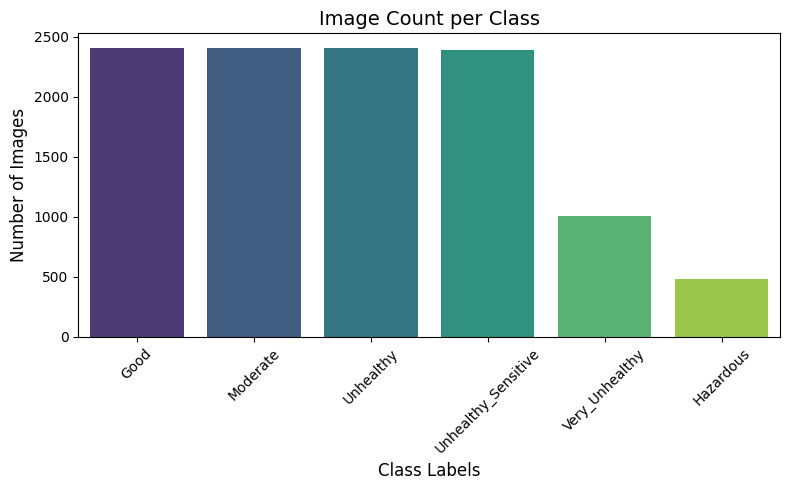

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This code displays a small gallery showing two random sample images from each air-quality class.
It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.
Useful for quick quality checks and understanding visual variation before model training.

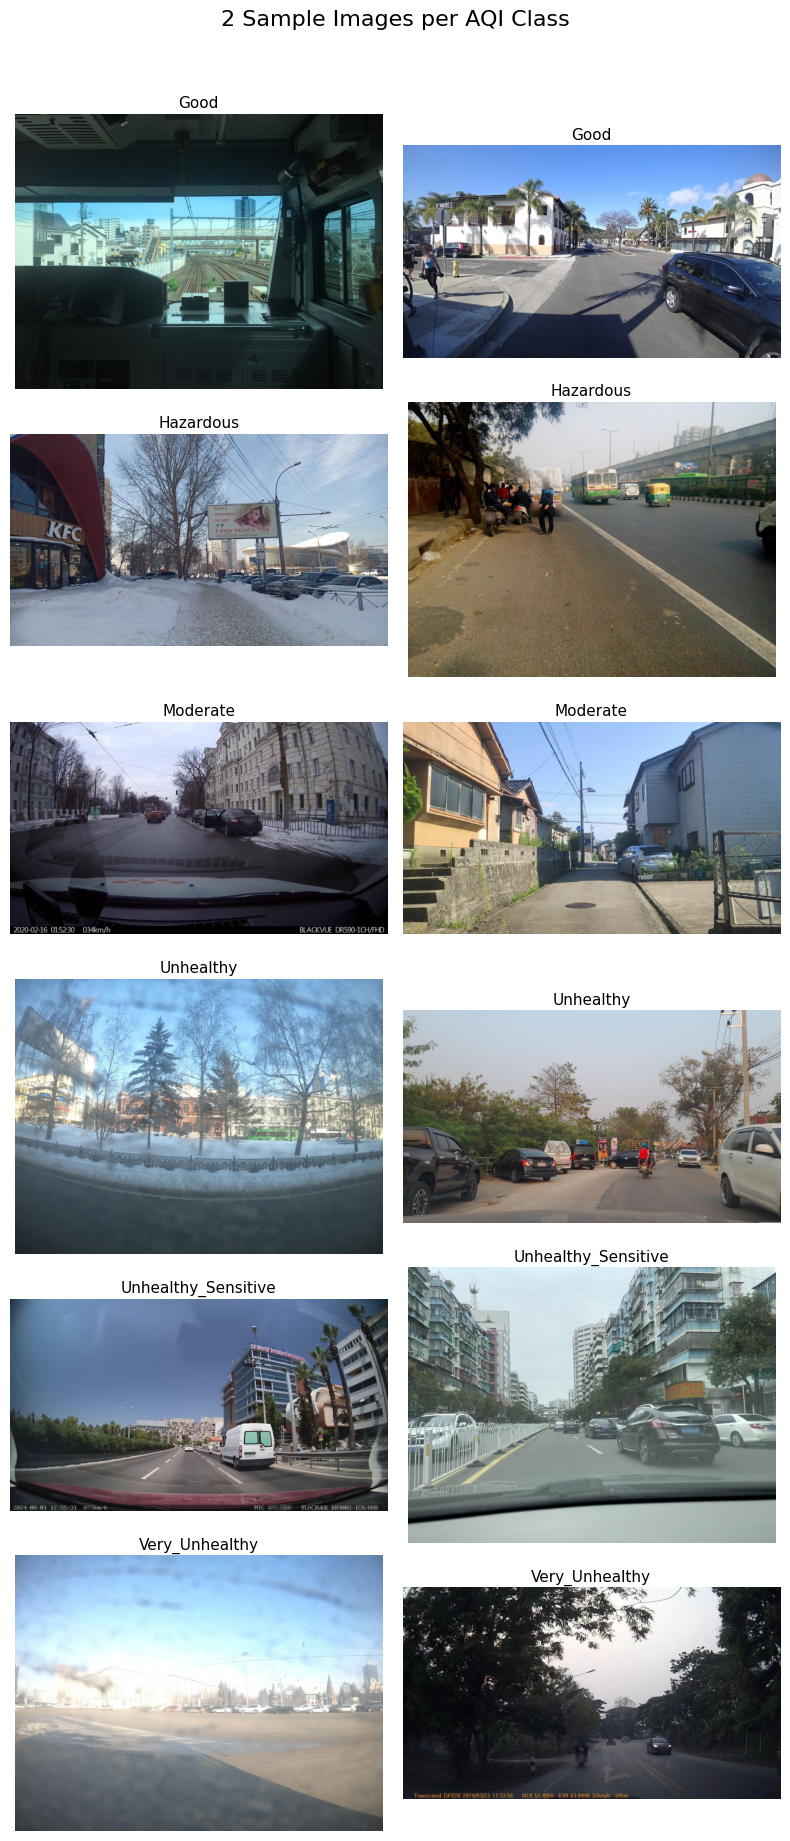

In [13]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

This block loads all image file paths and labels from the dataset directory, filtering only the specified PM2.5 classes. After loading, it prints the total number of images and the distribution across all air-quality categories to verify correct data preparation.

In [14]:
def load_split(split_dir, selected_classes=None):
    file_paths, labels = [], []
    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        if selected_classes and class_name not in selected_classes:
            continue
        for image_name in os.listdir(class_dir):
            file_paths.append(os.path.join(class_dir, image_name))
            labels.append(class_name)
    return pd.DataFrame({"file_path": file_paths, "label": labels})

PM25_CLASSES = [
    "Good",
    "Moderate",
    "Unhealthy_Sensitive",
    "Unhealthy",
    "Very_Unhealthy",
    "Hazardous"
]

data = load_split(data_dir, selected_classes=PM25_CLASSES)
print("Total images:", len(data))
print(data["label"].value_counts())


Total images: 11103
label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


This block splits the dataset into train, validation, and test sets using stratified sampling to preserve class balance. First, 80% is allocated for training, and the remaining 20% is split evenly into validation and test sets. The sizes of each split are printed for verification.

In [ ]:
train_df, temp_df = train_test_split(
    data,
    test_size=0.20,
    stratify=data["label"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,             
    stratify=temp_df["label"],
    random_state=42,
)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("Test size :", len(test_df))

print("\nTrain label counts:")
print(train_df["label"].value_counts())

print("\nVal label counts:")
print(val_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())


Train size: 8882
Val size  : 1110
Test size : 1111

Train label counts:
label
Unhealthy              1926
Good                   1926
Moderate               1925
Unhealthy_Sensitive    1914
Very_Unhealthy          806
Hazardous               385
Name: count, dtype: int64

Val label counts:
label
Moderate               241
Good                   241
Unhealthy              240
Unhealthy_Sensitive    239
Very_Unhealthy         101
Hazardous               48
Name: count, dtype: int64

Test label counts:
label
Good                   241
Unhealthy              241
Moderate               241
Unhealthy_Sensitive    240
Very_Unhealthy         100
Hazardous               48
Name: count, dtype: int64


This block prepares the labeled datasets and dataloaders for downstream classification. It defines a supervised ImageDataset that loads images, applies standard evaluation transforms, and maps class labels to numeric indices. Train, validation, and test loaders are created with the same preprocessing pipeline. The class-to-index mapping is printed for reference, and the total number of classes is determined for building the classifier head.

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform, is_lb=False):
        self.file_paths = dataframe["file_path"].values
        self.transform = transform
        self.is_lb = is_lb

        if self.is_lb:
            self.labels = dataframe["label"].values
            self.class_to_idx = {
                cls: idx for idx, cls in enumerate(sorted(set(self.labels)))
            }
            self.labels = np.array([self.class_to_idx[lbl] for lbl in self.labels])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, index):
        image_path = self.file_paths[index]
        image = Image.open(image_path).convert("RGB")

        if self.is_lb:
            label = self.labels[index]
            if self.transform is not None:
                image = self.transform(image)
            return image, label
        else:
            if self.transform is not None:
                image = self.transform(image)
            return image

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   
        std=[0.229, 0.224, 0.225],    
    ),
])

train_dataset = ImageDataset(train_df, transform=data_transform, is_lb=True)
val_dataset   = ImageDataset(val_df,   transform=data_transform, is_lb=True)
test_dataset  = ImageDataset(test_df,  transform=data_transform, is_lb=True)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

print("Class to index mapping:")
for cls, idx in train_dataset.class_to_idx.items():
    print(f"{cls:20s} --> {idx}")
num_classes = len(train_dataset.class_to_idx)
print("Num classes:", num_classes)


Class to index mapping:
Good                 --> 0
Hazardous            --> 1
Moderate             --> 2
Unhealthy            --> 3
Unhealthy_Sensitive  --> 4
Very_Unhealthy       --> 5
Num classes: 6


This block redefines the MoCo architecture so the pretext checkpoint can be loaded for downstream tasks. It includes the full query encoder, key encoder, momentum update, and queue logic, although only the query encoder will be used during evaluation and fine-tuning. A ResNet-50 encoder is also defined with its final layer replaced to output the contrastive embedding dimension used during pretraining.

In [ ]:
class MoCo(nn.Module):
    def __init__(self, base_encoder, dim=128, K=16384, m=0.999, T=0.2):
        super(MoCo, self).__init__()

        self.K = K
        self.m = m
        self.T = T

        self.encoder_q = base_encoder(num_classes=dim)
        self.encoder_k = base_encoder(num_classes=dim)

        for param_q, param_k in zip(self.encoder_q.parameters(),
                                    self.encoder_k.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False

        self.register_buffer("queue", torch.randn(dim, K))
        self.queue = F.normalize(self.queue, dim=0)

        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        for param_q, param_k in zip(self.encoder_q.parameters(),
                                    self.encoder_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1.0 - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        batch_size = keys.shape[0]
        assert batch_size <= self.K

        ptr = int(self.queue_ptr)
        end_ptr = ptr + batch_size

        if end_ptr <= self.K:
            self.queue[:, ptr:end_ptr] = keys.T
        else:
            overflow = end_ptr - self.K
            self.queue[:, ptr:] = keys[: batch_size - overflow].T
            self.queue[:, :overflow] = keys[batch_size - overflow :].T

        self.queue_ptr[0] = end_ptr % self.K

    def forward(self, im_q, im_k):
        q = self.encoder_q(im_q)
        q = F.normalize(q, dim=1)

        with torch.no_grad():
            self._momentum_update_key_encoder()
            k = self.encoder_k(im_k)
            k = F.normalize(k, dim=1)

        l_pos = torch.einsum("nc,nc->n", [q, k]).unsqueeze(-1)
        l_neg = torch.einsum("nc,ck->nk", [q, self.queue.clone().detach()])

        logits = torch.cat([l_pos, l_neg], dim=1)
        logits /= self.T

        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(logits.device)

        self._dequeue_and_enqueue(k)

        return logits, labels


def resnet50_encoder(num_classes):
    resnet = torchvision.models.resnet50(weights=None)
    resnet.fc = nn.Linear(2048, num_classes)   
    return resnet


This block rebuilds the MoCo model and loads the pretrained weights from the self-supervised checkpoint. Only the query encoder is used for downstream tasks, so it is placed in evaluation mode. The saved MoCo embeddings from pretext training are also loaded to determine the feature dimensionality for the linear classifier. Any missing or unexpected keys in the checkpoint are reported for verification.

In [ ]:
model = MoCo(
    base_encoder=resnet50_encoder,
    dim=128,
    K=16384,
    m=0.999,
    T=0.2,
).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)
state = checkpoint["model_state_dict"]

missing_keys, unexpected_keys = model.load_state_dict(state, strict=False)

print(f"Loaded MoCo checkpoint from epoch {checkpoint.get('epoch', 'N/A')}")
print("Missing keys   :", missing_keys)
print("Unexpected keys:", unexpected_keys)

encoder = model.encoder_q
encoder.eval()

moco_embeddings = np.load(embedding_path)
embeddings = moco_embeddings["embeddings"]
labels_embed = moco_embeddings["labels"]
feature_dim = embeddings.shape[1]

print("Embeddings shape:", embeddings.shape)
print("Feature dim (from embeddings):", feature_dim)


Loaded MoCo checkpoint from epoch 200
Missing keys   : []
Unexpected keys: ['encoder_q.total_ops', 'encoder_q.total_params', 'encoder_q.layer1.0.total_ops', 'encoder_q.layer1.0.total_params', 'encoder_q.layer1.1.total_ops', 'encoder_q.layer1.1.total_params', 'encoder_q.layer1.2.total_ops', 'encoder_q.layer1.2.total_params', 'encoder_q.layer2.0.total_ops', 'encoder_q.layer2.0.total_params', 'encoder_q.layer2.1.total_ops', 'encoder_q.layer2.1.total_params', 'encoder_q.layer2.2.total_ops', 'encoder_q.layer2.2.total_params', 'encoder_q.layer2.3.total_ops', 'encoder_q.layer2.3.total_params', 'encoder_q.layer3.0.total_ops', 'encoder_q.layer3.0.total_params', 'encoder_q.layer3.1.total_ops', 'encoder_q.layer3.1.total_params', 'encoder_q.layer3.2.total_ops', 'encoder_q.layer3.2.total_params', 'encoder_q.layer3.3.total_ops', 'encoder_q.layer3.3.total_params', 'encoder_q.layer3.4.total_ops', 'encoder_q.layer3.4.total_params', 'encoder_q.layer3.5.total_ops', 'encoder_q.layer3.5.total_params', 'enc

This block extracts frozen MoCo features for the train, validation, and test sets using the pretrained query encoder. Each image is passed through the encoder without gradient computation, and the resulting feature vectors and labels are collected. These fixed representations are later used for training shallow downstream classifiers such as linear or MLP heads.

In [19]:
def extract_features(encoder, dataloader, device):
    encoder.eval()
    all_feats = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            feats = encoder(images).flatten(start_dim=1)
            all_feats.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_feats = np.concatenate(all_feats, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_feats, all_labels

print("Extracting frozen features for train/val/test (for shallow heads)...")
X_tr, y_tr = extract_features(encoder, train_loader, device)
X_va, y_va = extract_features(encoder, val_loader, device)
X_te, y_te = extract_features(encoder, test_loader, device)

print("Train features:", X_tr.shape)
print("Val features  :", X_va.shape)
print("Test features :", X_te.shape)



Extracting frozen features for train/val/test (for shallow heads)...
Train features: (8882, 128)
Val features  : (1110, 128)
Test features : (1111, 128)


This block trains a linear classifier on top of the frozen MoCo encoder to evaluate the quality of the learned representations. A simple fully connected layer is defined, and only this layer is trained while the encoder remains fixed. The training loop computes accuracy and loss for both train and validation sets, logs performance each epoch, and saves the classifier with the best validation accuracy. This serves as a standard linear evaluation protocol for self-supervised models.

In [20]:
linear_train_loss_list = []
linear_val_loss_list = []
linear_train_acc_list = []
linear_val_acc_list = []
linear_epoch_time_list = []

class LinearProbe(nn.Module):
    def __init__(self, feature_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

linear_model = LinearProbe(feature_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_linear = torch.optim.Adam(
    linear_model.parameters(), lr=1e-3, weight_decay=1e-4
)

def run_linear_probe(encoder, clf, train_loader, val_loader, device, epochs):
    best_val_acc = 0.0
    history = []

    for epoch in range(epochs):
        epoch_start = time.time()

        # ---- Train ----
        encoder.eval()
        clf.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                feats = encoder(images)     # [B, 128]
                feats = feats.flatten(start_dim=1)

            outputs = clf(feats)
            loss = criterion(outputs, labels)

            optimizer_linear.zero_grad()
            loss.backward()
            optimizer_linear.step()

            running_loss += loss.item() * labels.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validate ----
        clf.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                feats = encoder(images)
                feats = feats.flatten(start_dim=1)

                outputs = clf(feats)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        epoch_time = time.time() - epoch_start

        linear_train_loss_list.append(train_loss)
        linear_val_loss_list.append(val_loss)
        linear_train_acc_list.append(train_acc)
        linear_val_acc_list.append(val_acc)
        linear_epoch_time_list.append(epoch_time)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "epoch_time": epoch_time,
        })

        print(
            f"[Linear] Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, "
            f"time={epoch_time:.2f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(clf.state_dict(), linear_classifier_path)

    return history

linear_history = run_linear_probe(
    encoder, linear_model, train_loader, val_loader, device, linear_epochs
)
print("Best linear-probe classifier saved to:", linear_classifier_path)


[Linear] Epoch 01 | train_loss=1.5168, train_acc=0.3709, val_loss=1.4267, val_acc=0.3856, time=70.16s
[Linear] Epoch 02 | train_loss=1.4161, train_acc=0.4117, val_loss=1.4623, val_acc=0.3838, time=70.04s
[Linear] Epoch 03 | train_loss=1.4066, train_acc=0.4139, val_loss=1.4024, val_acc=0.3883, time=69.61s
[Linear] Epoch 04 | train_loss=1.3934, train_acc=0.4180, val_loss=1.4267, val_acc=0.3991, time=68.93s
[Linear] Epoch 05 | train_loss=1.3915, train_acc=0.4218, val_loss=1.3935, val_acc=0.3937, time=70.20s
[Linear] Epoch 06 | train_loss=1.3792, train_acc=0.4211, val_loss=1.3918, val_acc=0.3946, time=69.65s
[Linear] Epoch 07 | train_loss=1.3686, train_acc=0.4300, val_loss=1.3948, val_acc=0.3919, time=69.69s
[Linear] Epoch 08 | train_loss=1.3755, train_acc=0.4202, val_loss=1.3773, val_acc=0.3919, time=69.78s
[Linear] Epoch 09 | train_loss=1.3749, train_acc=0.4256, val_loss=1.4474, val_acc=0.4009, time=69.69s
[Linear] Epoch 10 | train_loss=1.3697, train_acc=0.4279, val_loss=1.4293, val_acc=

This block evaluates the best linear classifier on the test set using the frozen MoCo encoder. It computes test loss, accuracy, inference time, and generates detailed evaluation metrics including a classification report, confusion matrix, and per-class ROC curves. This provides a comprehensive assessment of the representation quality learned during MoCo pretraining.

Test Loss: 1.455, Test Accuracy: 0.412
Total Test Time: 7.88 seconds for 1111 images
Average Inference Time per Image: 0.007094 s

Classification Report:
              precision    recall  f1-score   support

           0     0.4982    0.5851    0.5382       241
           1     0.5833    0.2917    0.3889        48
           2     0.3224    0.2863    0.3033       241
           3     0.4006    0.5187    0.4521       241
           4     0.3644    0.3417    0.3527       240
           5     0.5094    0.2700    0.3529       100

    accuracy                         0.4122      1111
   macro avg     0.4464    0.3822    0.3980      1111
weighted avg     0.4147    0.4122    0.4054      1111



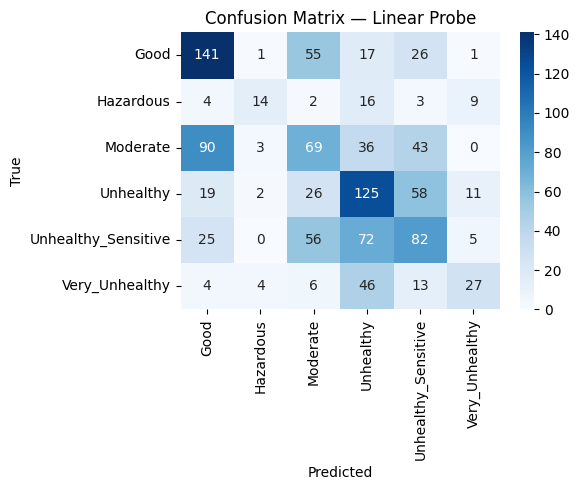

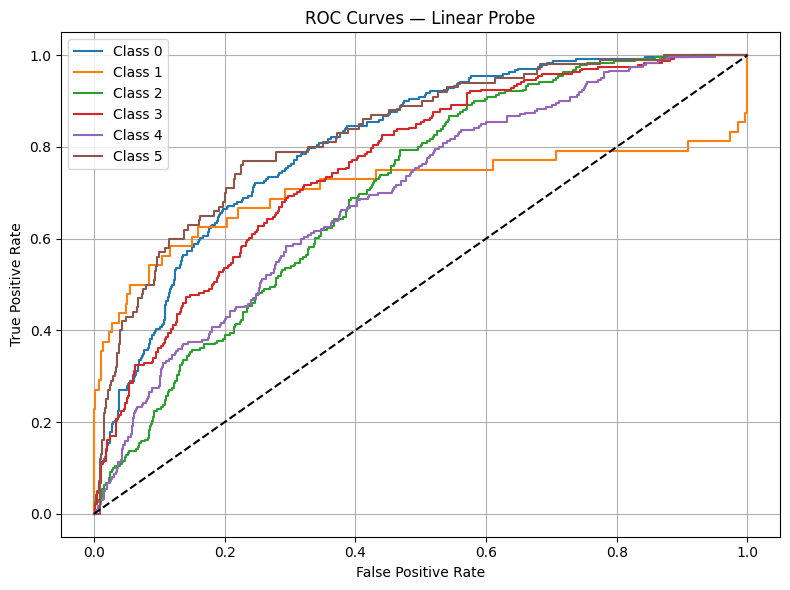

In [21]:
best_linear = LinearProbe(feature_dim, num_classes).to(device)
best_linear.load_state_dict(torch.load(linear_classifier_path, map_location=device))
best_linear.eval()
encoder.eval()

test_loss = 0.0
test_total = 0
all_preds = []
all_labels = []
all_probs = []

test_start = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        feats = encoder(images).flatten(start_dim=1)
        outputs = best_linear(feats)

        loss = criterion(outputs, labels)
        test_loss += loss.item() * labels.size(0)
        test_total += labels.size(0)

        probs = torch.softmax(outputs, dim=1)
        _, preds = probs.max(1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.append(probs.cpu().numpy())

test_time = time.time() - test_start
all_probs = np.concatenate(all_probs, axis=0)

test_loss = test_loss / test_total
linear_test_acc = accuracy_score(all_labels, all_preds)

print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {linear_test_acc:.3f}")
print(f"Total Test Time: {test_time:.2f} seconds for {len(test_dataset)} images")
print(f"Average Inference Time per Image: {test_time / len(test_dataset):.6f} s\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=sorted(train_dataset.class_to_idx.keys()),
    yticklabels=sorted(train_dataset.class_to_idx.keys()),
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Linear Probe")
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((np.array(all_labels) == i).astype(int), all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Linear Probe")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


This block performs a k-NN evaluation on the frozen MoCo feature embeddings. A k-nearest neighbors classifier is trained directly on the extracted features without any additional learning, providing a quick measure of representation quality. Accuracy is reported for multiple k values (1, 5, 20) to assess how well the embeddings cluster by class.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def knn_eval(Xtrain, ytrain, Xtest, ytest, k):
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(Xtrain, ytrain)
    ypred = knn.predict(Xtest)
    return accuracy_score(ytest, ypred)

print("\n=== k-NN Accuracy on Frozen MoCo Features ===")
for k in [1, 5, 20]:
    acc = knn_eval(X_tr, y_tr, X_te, y_te, k)
    print(f"k={k:2d}: {acc:.4f}")



=== k-NN Accuracy on Frozen MoCo Features ===
k= 1: 0.6013
k= 5: 0.5698
k=20: 0.5545


This block evaluates label efficiency by training a linear probe on progressively smaller fractions of the labeled training set, while keeping the MoCo encoder frozen. For each fraction, a new linear classifier is trained briefly and then tested on the full MoCo test embeddings. The results show how well MoCo representations perform with limited labeled data. A final plot visualizes accuracy vs. percentage of labels.


===== Label Efficiency — Linear Probe on MoCo Features =====
 1% labels → Linear-probe accuracy = 0.2079
 5% labels → Linear-probe accuracy = 0.1917
10% labels → Linear-probe accuracy = 0.2196
25% labels → Linear-probe accuracy = 0.2007
50% labels → Linear-probe accuracy = 0.2097


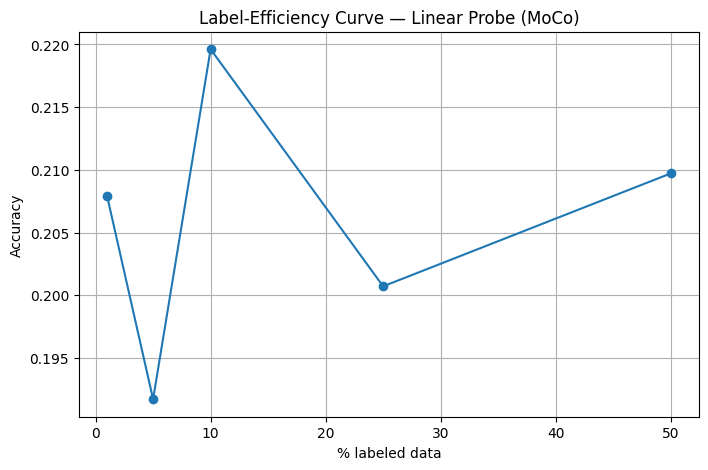

In [ ]:

fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
efficiency_results = {}

print("\n===== Label Efficiency — Linear Probe on MoCo Features =====")

for frac in fractions:
    n = int(len(X_tr) * frac)

    idx = np.random.choice(len(X_tr), size=n, replace=False)
    X_sub = X_tr[idx]        
    y_sub = y_tr[idx]

    clf = LinearProbe(feature_dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(clf.parameters(), lr=1e-3)
    criterion_local = nn.CrossEntropyLoss()

    feats = torch.tensor(X_sub, dtype=torch.float32).to(device)
    labels = torch.tensor(y_sub, dtype=torch.long).to(device)

    for epoch in range(5):
        clf.train()
        outputs = clf(feats)
        loss = criterion_local(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    clf.eval()
    Xtest = torch.tensor(X_te, dtype=torch.float32).to(device)

    with torch.no_grad():
        out = clf(Xtest).cpu().numpy()

    preds = out.argmax(axis=1)
    acc = accuracy_score(y_te, preds)
    efficiency_results[frac] = acc

    print(f"{int(frac*100):2d}% labels → Linear-probe accuracy = {acc:.4f}")

plt.figure(figsize=(8,5))
plt.plot(
    [f*100 for f in fractions],
    [efficiency_results[f] for f in fractions],
    marker='o'
)
plt.xlabel("% labeled data")
plt.ylabel("Accuracy")
plt.title("Label-Efficiency Curve — Linear Probe (MoCo)")
plt.grid(True)
plt.show()


This block benchmarks several shallow classifiers on the frozen MoCo feature embeddings to compare how well different traditional ML models perform on top of the learned representation. It trains and evaluates an MLP, SVM, Decision Tree, and Random Forest using the extracted train/test features and reports their classification accuracy and detailed metrics. A summary table is printed to compare all shallow heads.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

results_shallow = {}

print("\n===== Shallow Heads on Frozen MoCo Features =====")

mlp_clf = MLPClassifier(hidden_layer_sizes=(256,), max_iter=200, random_state=42)
mlp_clf.fit(X_tr, y_tr)

y_pred_mlp = mlp_clf.predict(X_te)
acc_mlp = accuracy_score(y_te, y_pred_mlp)
results_shallow["MLP"] = acc_mlp

print("\n[MLP] Test Accuracy:", acc_mlp)
print(classification_report(y_te, y_pred_mlp, digits=4))

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_tr, y_tr)

y_pred_svm = svm_clf.predict(X_te)
acc_svm = accuracy_score(y_te, y_pred_svm)
results_shallow["SVM"] = acc_svm

print("\n[SVM] Test Accuracy:", acc_svm)
print(classification_report(y_te, y_pred_svm, digits=4))

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_tr, y_tr)

y_pred_dt = dt_clf.predict(X_te)
acc_dt = accuracy_score(y_te, y_pred_dt)
results_shallow["DecisionTree"] = acc_dt

print("\n[Decision Tree] Test Accuracy:", acc_dt)
print(classification_report(y_te, y_pred_dt, digits=4))

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_tr, y_tr)

y_pred_rf = rf_clf.predict(X_te)
acc_rf = accuracy_score(y_te, y_pred_rf)
results_shallow["RandomForest"] = acc_rf

print("\n[Random Forest] Test Accuracy:", acc_rf)
print(classification_report(y_te, y_pred_rf, digits=4))


print("\n=== Shallow Head Summary (Frozen MoCo Features) ===")
for k, v in results_shallow.items():
    print(f"{k:15s}: {v:.4f}")



===== Shallow Heads on Frozen MoCo Features =====

[MLP] Test Accuracy: 0.5436543654365437
              precision    recall  f1-score   support

           0     0.4882    0.4274    0.4558       241
           1     0.6545    0.7500    0.6990        48
           2     0.4232    0.4689    0.4449       241
           3     0.6534    0.6805    0.6667       241
           4     0.5259    0.5083    0.5169       240
           5     0.6947    0.6600    0.6769       100

    accuracy                         0.5437      1111
   macro avg     0.5733    0.5825    0.5767      1111
weighted avg     0.5438    0.5437    0.5428      1111


[SVM] Test Accuracy: 0.495949594959496
              precision    recall  f1-score   support

           0     0.5035    0.6017    0.5482       241
           1     1.0000    0.3750    0.5455        48
           2     0.4185    0.3195    0.3624       241
           3     0.5121    0.6141    0.5585       241
           4     0.4399    0.5333    0.4821       240


This block performs full supervised fine-tuning of the MoCo encoder by attaching a classification head and unfreezing the entire backbone. A FineTuneModel wrapper combines the pretrained encoder with a new linear classifier. The training loop optimizes both modules using different learning rates, tracks loss and accuracy for train/validation sets, and saves the best-performing fine-tuned model. This stage evaluates how well the MoCo-pretrained weights transfer when fully adapted to the downstream task.

In [ ]:
class FineTuneModel(nn.Module):
    def __init__(self, encoder, feature_dim, num_classes):
        super().__init__()
        self.backbone = encoder
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        feats = self.backbone(x).flatten(start_dim=1)
        out = self.classifier(feats)
        return out

finetune_model = FineTuneModel(encoder, feature_dim, num_classes).to(device)

for p in finetune_model.backbone.parameters():
    p.requires_grad = True

optimizer_ft = torch.optim.AdamW(
    [
        {"params": finetune_model.backbone.parameters(), "lr": 1e-4},
        {"params": finetune_model.classifier.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4,
)

criterion_ft = nn.CrossEntropyLoss()

def train_finetune(model, train_loader, val_loader, device, epochs):
    best_val_acc = 0.0
    history = []

    for epoch in range(epochs):
        epoch_start = time.time()

        # ---- Train ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion_ft(outputs, labels)

            optimizer_ft.zero_grad()
            loss.backward()
            optimizer_ft.step()

            running_loss += loss.item() * labels.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validate ----
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion_ft(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        epoch_time = time.time() - epoch_start

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "epoch_time": epoch_time,
        })

        print(
            f"[FineTune] Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, "
            f"time={epoch_time:.2f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), finetune_model_path)

    return history

finetune_history = train_finetune(
    finetune_model, train_loader, val_loader, device, finetune_epochs
)

print("Best fine-tuned model saved to:", finetune_model_path)


[FineTune] Epoch 01 | train_loss=1.3337, train_acc=0.4390, val_loss=1.2387, val_acc=0.4748, time=75.52s
[FineTune] Epoch 02 | train_loss=1.0664, train_acc=0.5548, val_loss=1.1915, val_acc=0.5036, time=76.35s
[FineTune] Epoch 03 | train_loss=0.8836, train_acc=0.6383, val_loss=1.0748, val_acc=0.5468, time=76.60s
[FineTune] Epoch 04 | train_loss=0.6873, train_acc=0.7154, val_loss=1.1573, val_acc=0.5541, time=75.22s
[FineTune] Epoch 05 | train_loss=0.5155, train_acc=0.7915, val_loss=1.3771, val_acc=0.5450, time=75.50s
[FineTune] Epoch 06 | train_loss=0.3751, train_acc=0.8494, val_loss=1.4501, val_acc=0.5667, time=76.05s
[FineTune] Epoch 07 | train_loss=0.2447, train_acc=0.9046, val_loss=1.7948, val_acc=0.5694, time=75.45s
[FineTune] Epoch 08 | train_loss=0.2165, train_acc=0.9187, val_loss=1.9468, val_acc=0.5532, time=75.72s
[FineTune] Epoch 09 | train_loss=0.1686, train_acc=0.9375, val_loss=1.9592, val_acc=0.5649, time=75.30s
[FineTune] Epoch 10 | train_loss=0.1271, train_acc=0.9516, val_l

This block performs full downstream evaluation using the best linear probe and the best fine-tuned MoCo model. It first tests the frozen-encoder linear classifier, computing loss, accuracy, inference time, a classification report, confusion matrix, and per-class ROC curves. Then it loads the fully fine-tuned model and evaluates it on the test set in the same manner. Finally, a summary compares linear-probe accuracy, fine-tuned accuracy, and shallow-head baselines, providing a complete view of downstream performance using MoCo representations.

Test Loss: 1.380, Test Accuracy: 0.525
Total Test Time: 7.89 seconds for 1111 images
Average Inference Time per Image: 0.007098 s

Classification Report:
              precision    recall  f1-score   support

           0     0.4933    0.6100    0.5455       241
           1     0.1667    0.0625    0.0909        48
           2     0.3356    0.4025    0.3660       241
           3     0.7474    0.6017    0.6667       241
           4     0.6132    0.5417    0.5752       240
           5     0.6100    0.6100    0.6100       100

    accuracy                         0.5248      1111
   macro avg     0.4944    0.4714    0.4757      1111
weighted avg     0.5365    0.5248    0.5254      1111



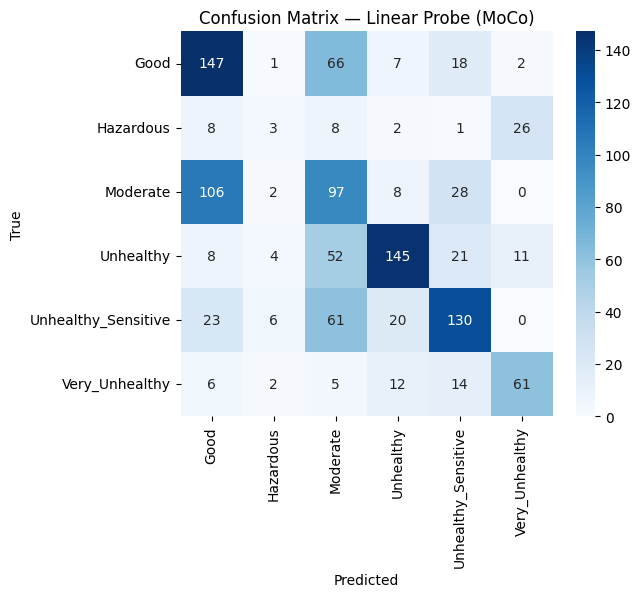

ROC–AUC (macro): 0.8208


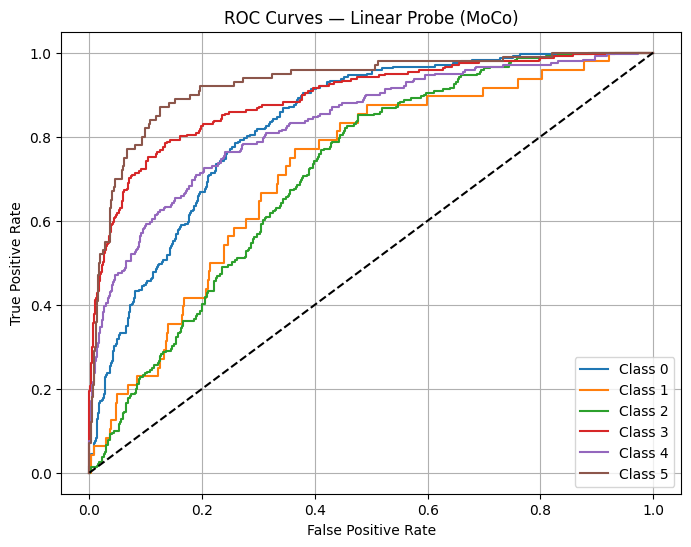


[Fine-Tune] Test Accuracy: 0.6175
              precision    recall  f1-score   support

           0     0.5685    0.5851    0.5767       241
           1     0.8205    0.6667    0.7356        48
           2     0.4256    0.5104    0.4642       241
           3     0.7559    0.7967    0.7758       241
           4     0.6961    0.5250    0.5986       240
           5     0.7200    0.7200    0.7200       100

    accuracy                         0.6175      1111
   macro avg     0.6645    0.6340    0.6451      1111
weighted avg     0.6303    0.6175    0.6200      1111



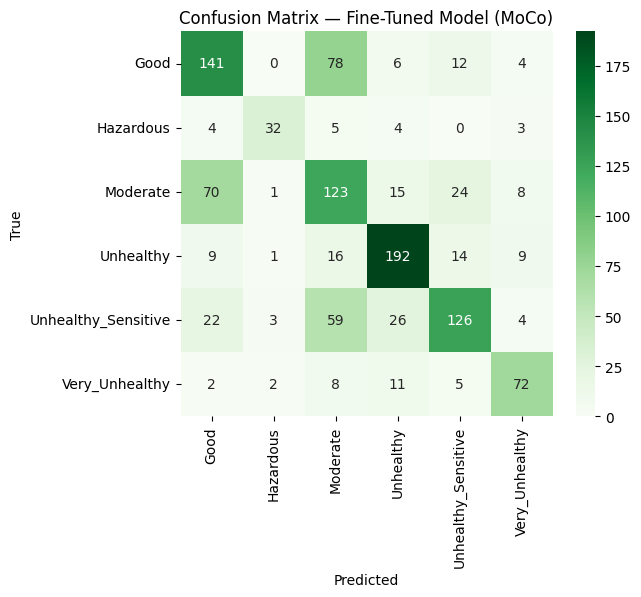


=== Summary: Linear vs Fine-Tune (Test Accuracy) ===
Linear Probe : 0.5248
Fine-Tune    : 0.6175

=== Shallow Heads (Frozen MoCo Features) ===
MLP            : 0.5437
SVM            : 0.4959
DecisionTree   : 0.4149
RandomForest   : 0.5887


In [ ]:
best_linear = LinearProbe(feature_dim, num_classes).to(device)
best_linear.load_state_dict(torch.load(linear_classifier_path, map_location=device))
best_linear.eval()

encoder.eval()

test_loss = 0.0
test_total = 0
all_preds = []
all_labels = []
all_probs = []

test_start = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        feats = encoder(images)
        feats = feats.flatten(start_dim=1)   

        outputs = best_linear(feats)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * labels.size(0)
        test_total += labels.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_time = time.time() - test_start
avg_time = test_time / len(test_dataset)
test_loss /= test_total

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

linear_test_acc = accuracy_score(all_labels, all_preds)

print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {linear_test_acc:.3f}")
print(f"Total Test Time: {test_time:.2f} seconds for {len(test_dataset)} images")
print(f"Average Inference Time per Image: {avg_time:.6f} s\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)

sorted_labels = sorted(train_dataset.class_to_idx, key=train_dataset.class_to_idx.get)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sorted_labels,
    yticklabels=sorted_labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Linear Probe (MoCo)")
plt.show()

from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
print(f"ROC–AUC (macro): {roc_auc:.4f}")

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Linear Probe (MoCo)")
plt.legend()
plt.grid(True)
plt.show()


best_finetune_model = FineTuneModel(encoder, feature_dim, num_classes).to(device)
best_finetune_model.load_state_dict(torch.load(finetune_model_path, map_location=device))
best_finetune_model.eval()

all_preds_ft = []
all_labels_ft = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_finetune_model(images)
        preds = outputs.argmax(dim=1)

        all_preds_ft.extend(preds.cpu().numpy())
        all_labels_ft.extend(labels.cpu().numpy())

all_preds_ft = np.array(all_preds_ft)
all_labels_ft = np.array(all_labels_ft)

finetune_test_acc = accuracy_score(all_labels_ft, all_preds_ft)

print(f"\n[Fine-Tune] Test Accuracy: {finetune_test_acc:.4f}")
print(classification_report(all_labels_ft, all_preds_ft, digits=4))

cm_ft = confusion_matrix(all_labels_ft, all_preds_ft)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_ft, annot=True, fmt='d', cmap='Greens',
    xticklabels=sorted_labels,
    yticklabels=sorted_labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Fine-Tuned Model (MoCo)")
plt.show()

print("\n=== Summary: Linear vs Fine-Tune (Test Accuracy) ===")
print(f"Linear Probe : {linear_test_acc:.4f}")
print(f"Fine-Tune    : {finetune_test_acc:.4f}")

print("\n=== Shallow Heads (Frozen MoCo Features) ===")
for k, v in results_shallow.items():
    print(f"{k:15s}: {v:.4f}")
